# Table VI key compound comparison: 11a, Milrinone, and 23

This notebook compares three key compounds from the curated Table VI dataset:

- **11a**: E-1020 candidate / hydrochloride monohydrate-related compound
- **Milrinone**: reference drug in Table VI
- **23**: 7-yl isomer and an important weak comparator

The goal is not to claim that ED50 alone explains E-1020 selection. The goal is to create a small, transparent comparison that shows why **11a vs Milrinone** and **11a vs 23** are useful starting points for learning drug-discovery data interpretation.

**Important caution:** The 11a vs 23 activity-cliff interpretation is preliminary until structure metadata and SMILES are curated and independently checked.


## Learning goals

By the end of this notebook, you should be able to:

1. Load the verified Table VI curated dataset.
2. Extract the rows for 11a, Milrinone, and 23.
3. Compare exact and right-censored ED50 values without treating censored values as exact measurements.
4. Compare LVDp/dtmax, heart-rate, and mean arterial pressure changes.
5. Explain why ED50 ranking alone is insufficient to explain historical compound selection.


In [26]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)


## Locate and load the curated Table VI dataset

This notebook is designed to work when executed either from the repository root or from the `notebooks/` directory.


In [27]:
def find_repo_root(start=None):
    """Find the repository root by looking for the curated Table VI CSV."""
    start = Path.cwd() if start is None else Path(start)
    candidates = [start, *start.parents]
    for candidate in candidates:
        data_path = candidate / "data" / "curated" / "e1020_table_vi_v0.csv"
        if data_path.exists():
            return candidate
    raise FileNotFoundError("Could not find data/curated/e1020_table_vi_v0.csv. "
        "Run this notebook from inside the e1020-ai-rediscovery repository.")

# REPO_ROOT = find_repo_root() # This line caused the error
REPO_ROOT = Path.cwd() # Set REPO_ROOT to current directory since data file is here
#DATA_PATH = REPO_ROOT / "data" / "curated" / "e1020_table_vi_v0.csv"
DATA_PATH = "e1020_table_vi_v0.csv"

print(f"Repository root: {REPO_ROOT}")
print(f"Dataset: {DATA_PATH}")

df = pd.read_csv(DATA_PATH)
print(f"Rows: {len(df)}")
print(f"Columns: {len(df.columns)}")
df.head()


Repository root: /content
Dataset: e1020_table_vi_v0.csv
Rows: 35
Columns: 16


,compound_id,source_table,number_of_experiments,dose_mg_per_kg,lv_dpdt_pct_change,hr_pct_change,map_pct_change,ed50_ug_per_kg,ed50_relation,ed50_error,notes,ed50_censored,active_class,iv_potency_class,curation_status,curation_note
0,3a,Table VI,5,0.1,75,18,-17,52,=,10.0,NaN,none,moderate,moderate,manual_checked,source values checked against Table VI
1,3b,Table VI,2,0.3,15,4,-5,300,>,NaN,NaN,right,weak,weak,manual_checked,source values checked against Table VI
2,3c,Table VI,2,0.1,22,11,-15,300,>,NaN,NaN,right,weak,weak,manual_checked,source values checked against Table VI
3,3d,Table VI,2,0.3,19,3,-12,300,>,NaN,NaN,right,weak,weak,manual_checked,source values checked against Table VI
4,3e,Table VI,3,0.1,97,27,-27,31,=,14.0,NaN,none,moderate,moderate,manual_checked,source values checked against Table VI


## Basic dataset checks

Before comparing compounds, check that key columns are present and that source verification status is available.


In [28]:
required_columns = [
    "compound_id",
    "dose_mg_per_kg",
    "lv_dpdt_pct_change",
    "hr_pct_change",
    "map_pct_change",
    "ed50_ug_per_kg",
    "ed50_relation",
    "ed50_censored",
    "iv_potency_class",
]

missing_columns = [col for col in required_columns if col not in df.columns]
if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

print("Required columns are present.")

if "curation_status" in df.columns:
    print("curation_status counts:")
    display(df["curation_status"].value_counts(dropna=False).to_frame("count"))
else:
    print("Note: curation_status column is not present in this local dataset version.")

print("ed50_relation counts:")
display(df["ed50_relation"].value_counts(dropna=False).to_frame("count"))

print("ed50_censored counts:")
display(df["ed50_censored"].value_counts(dropna=False).to_frame("count"))


Required columns are present.
curation_status counts:


,count
curation_status,
manual_checked,35


ed50_relation counts:


,count
ed50_relation,
=,20
>,15


ed50_censored counts:


,count
ed50_censored,
none,20
right,15


## Extract key compounds

We focus on:

- `11a`
- `Milrinone`
- `23`

If the dataset uses slightly different capitalization or whitespace, the helper code below still tries to find the expected rows.


In [29]:
df = df.copy()
df["compound_id_norm"] = df["compound_id"].astype(str).str.strip().str.lower()

key_id_map = {
    "11a": "11a",
    "milrinone": "Milrinone",
    "23": "23",
}

key = df[df["compound_id_norm"].isin(key_id_map.keys())].copy()
key["compound_label"] = key["compound_id_norm"].map(key_id_map)

found = set(key["compound_id_norm"])
missing = set(key_id_map) - found
if missing:
    raise ValueError(f"Missing key compounds in dataset: {sorted(missing)}")

# Put rows in the intended narrative order.
order = pd.CategoricalDtype(["11a", "Milrinone", "23"], ordered=True)
key["compound_label"] = key["compound_label"].astype(order)
key = key.sort_values("compound_label").reset_index(drop=True)

key


,compound_id,source_table,number_of_experiments,dose_mg_per_kg,lv_dpdt_pct_change,hr_pct_change,map_pct_change,ed50_ug_per_kg,ed50_relation,ed50_error,notes,ed50_censored,active_class,iv_potency_class,curation_status,curation_note,compound_id_norm,compound_label
0,11a,Table VI,6,0.1,99,28,-9,23,=,2.0,E-1020 free base / hydrochloride monohydrate s...,none,strong,strong,manual_checked,source values checked against Table VI,11a,11a
1,Milrinone,Table VI,6,0.1,98,33,-18,25,=,6.0,reference drug,none,strong,strong,manual_checked,source values checked against Table VI,milrinone,Milrinone
2,23,Table VI,2,1.0,25,11,-11,1000,>,NaN,7-yl isomer; weak activity,right,weak,weak,manual_checked,source values checked against Table VI,23,23


## Make an interpretable comparison table

The raw numeric `ed50_ug_per_kg` column stores the threshold value for right-censored ED50 rows. For example, `>1000` is stored as `1000` with `ed50_relation = ">"` and `ed50_censored = "right"`.

That means we need a display column that preserves the relation symbol.


In [30]:
def format_number(x):
    if pd.isna(x):
        return ""
    try:
        x_float = float(x)
        if x_float.is_integer():
            return str(int(x_float))
        return f"{x_float:g}"
    except Exception:
        return str(x)


def format_ed50(row) -> str:
    relation = str(row.get("ed50_relation", "")).strip()
    value = format_number(row.get("ed50_ug_per_kg"))
    error = row.get("ed50_error", None)

    if relation == ">":
        return f">{value}"
    if pd.notna(error) and str(error).strip() != "":
        return f"{value} ± {format_number(error)}"
    return value

key["ed50_display"] = key.apply(format_ed50, axis=1)
key["ed50_type"] = key["ed50_censored"].map({"none": "exact", "right": "right_censored"}).fillna("unknown")

comparison_columns = [
    "compound_label",
    "dose_mg_per_kg",
    "lv_dpdt_pct_change",
    "hr_pct_change",
    "map_pct_change",
    "ed50_display",
    "ed50_type",
    "iv_potency_class",
]

if "curation_status" in key.columns:
    comparison_columns.append("curation_status")
if "curation_note" in key.columns:
    comparison_columns.append("curation_note")
if "notes" in key.columns:
    comparison_columns.append("notes")

key_comparison = key[comparison_columns].copy()
key_comparison


,compound_label,dose_mg_per_kg,lv_dpdt_pct_change,hr_pct_change,map_pct_change,ed50_display,ed50_type,iv_potency_class,curation_status,curation_note,notes
0,11a,0.1,99,28,-9,23 ± 2,exact,strong,manual_checked,source values checked against Table VI,E-1020 free base / hydrochloride monohydrate s...
1,Milrinone,0.1,98,33,-18,25 ± 6,exact,strong,manual_checked,source values checked against Table VI,reference drug
2,23,1.0,25,11,-11,>1000,right_censored,weak,manual_checked,source values checked against Table VI,7-yl isomer; weak activity


## Compare ED50 values carefully

Lower exact ED50 values indicate stronger IV inotropic potency in this Table VI context. However, right-censored values such as `>1000` are not exact values.

So:

- 11a and Milrinone can be compared directly because both have exact ED50 values.
- 23 should not be treated as exactly `1000`; it is only known to be greater than `1000` in the source table.


In [31]:
ed50_view = key[[
    "compound_label",
    "ed50_ug_per_kg",
    "ed50_relation",
    "ed50_display",
    "ed50_type",
    "iv_potency_class",
]].copy()

ed50_view


,compound_label,ed50_ug_per_kg,ed50_relation,ed50_display,ed50_type,iv_potency_class
0,11a,23,=,23 ± 2,exact,strong
1,Milrinone,25,=,25 ± 6,exact,strong
2,23,1000,>,>1000,right_censored,weak


In [32]:
# Direct exact ED50 comparison: 11a vs Milrinone
ed50_11a = key.loc[key["compound_label"].astype(str) == "11a", "ed50_ug_per_kg"].iloc[0]
ed50_milrinone = key.loc[key["compound_label"].astype(str) == "Milrinone", "ed50_ug_per_kg"].iloc[0]
ed50_23_threshold = key.loc[key["compound_label"].astype(str) == "23", "ed50_ug_per_kg"].iloc[0]

milrinone_vs_11a_ratio = ed50_milrinone / ed50_11a
compound_23_lower_bound_ratio = ed50_23_threshold / ed50_11a

summary = pd.DataFrame(
    [
        {
            "comparison": "Milrinone ED50 / 11a ED50",
            "interpretation": "Exact comparison; values are close in Table VI",
            "value": milrinone_vs_11a_ratio,
        },
        {
            "comparison": "23 ED50 threshold / 11a ED50",
            "interpretation": "Lower-bound comparison only because 23 is right-censored as >1000",
            "value": compound_23_lower_bound_ratio,
        },
    ]
)

summary["value"] = summary["value"].map(lambda x: f"{x:.1f}x")
summary


,comparison,interpretation,value
0,Milrinone ED50 / 11a ED50,Exact comparison; values are close in Table VI,1.1x
1,23 ED50 threshold / 11a ED50,Lower-bound comparison only because 23 is righ...,43.5x


### Interpretation of ED50 comparison

- **11a vs Milrinone:** Both have exact ED50 values and both fall into the coarse `strong` IV potency class. Their Table VI ED50 values are close, so this is a useful reference-drug comparison.
- **11a vs 23:** Compound 23 is right-censored as `>1000`, so it should be interpreted as **at least** much weaker by ED50 than 11a in Table VI. This makes 11a vs 23 a useful preliminary activity-cliff case, but the structural interpretation must wait until structure metadata and SMILES are curated.


## Compare cardiovascular response profile

Table VI also includes cardiovascular response measurements at the tested dose:

- `lv_dpdt_pct_change`: percent change in LVDp/dtmax
- `hr_pct_change`: percent change in heart rate
- `map_pct_change`: percent change in mean arterial pressure

These values matter because compound selection is not only about ED50. A historically plausible selection logic may involve multiple pharmacological objectives.


In [33]:
profile_columns = [
    "compound_label",
    "dose_mg_per_kg",
    "lv_dpdt_pct_change",
    "hr_pct_change",
    "map_pct_change",
    "ed50_display",
    "ed50_type",
]

profile = key[profile_columns].copy()
profile


,compound_label,dose_mg_per_kg,lv_dpdt_pct_change,hr_pct_change,map_pct_change,ed50_display,ed50_type
0,11a,0.1,99,28,-9,23 ± 2,exact
1,Milrinone,0.1,98,33,-18,25 ± 6,exact
2,23,1.0,25,11,-11,>1000,right_censored


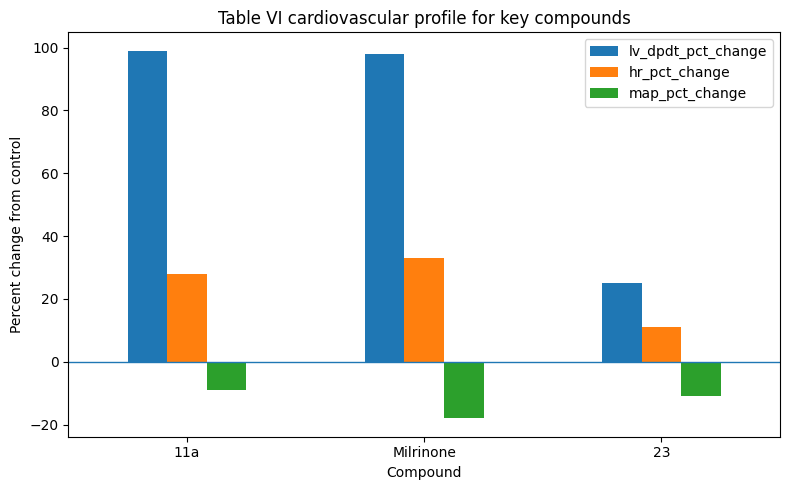

In [34]:
plot_df = key.set_index(key["compound_label"].astype(str))[
    ["lv_dpdt_pct_change", "hr_pct_change", "map_pct_change"]
].copy()

ax = plot_df.plot(kind="bar", figsize=(8, 5))
ax.set_title("Table VI cardiovascular profile for key compounds")
ax.set_xlabel("Compound")
ax.set_ylabel("Percent change from control")
ax.axhline(0, linewidth=1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## Preliminary interpretation

This small comparison supports three cautious points:

1. **11a appears strong in Table VI**, but it is not meaningful to treat this as a complete drug-selection explanation.
2. **Milrinone provides a reference-drug context**: 11a and Milrinone have close exact ED50 values in this dataset, with different accompanying cardiovascular profiles.
3. **Compound 23 is a key weak comparator**: its ED50 is right-censored as `>1000`, making it an important contrast to 11a. However, the 11a vs 23 activity-cliff interpretation should remain preliminary until structural metadata and SMILES are curated.

In short, this comparison is useful because it moves the project from a simple potency ranking toward a more drug-discovery-like question:

> What combination of potency, cardiovascular profile, oral duration, PDE selectivity, safety, and chemical structure could have supported the historical selection of E-1020?


## Optional export

The next cell exports the key comparison table to `data/derived/table_vi_key_compound_comparison_v0.csv`. This is optional, but useful if you want a lightweight table for documentation.


In [35]:
DERIVED_DIR = REPO_ROOT / "data" / "derived"
DERIVED_DIR.mkdir(parents=True, exist_ok=True)

EXPORT_PATH = DERIVED_DIR / "table_vi_key_compound_comparison_v0.csv"
key_comparison.to_csv(EXPORT_PATH, index=False)

print(f"Exported: {EXPORT_PATH.relative_to(REPO_ROOT)}")


Exported: data/derived/table_vi_key_compound_comparison_v0.csv


## Next steps

Recommended next analyses:

1. Add `docs/key_compound_comparison_notes.md` summarizing this comparison.
2. Curate Table VIII oral-duration data.
3. Curate Table IX PDE inhibition data.
4. Add structure metadata from Tables I, IV, and V.
5. Curate and validate SMILES for 11a, 23, Milrinone, and key analogs.

Do not over-interpret the 11a vs 23 activity cliff until chemical structures are curated and checked.
